# Flight Delay Prediction System — Charlotte Douglas Intl (KCLT)


**Important note on data:** the Aviation Weather Center API only gives us
*weather* (METAR observations). It has no idea whether a flight was delayed.
To train a real model we need a second dataset with actual flight delay
outcomes, joined to the weather ahead of departure. The standard free source
for that is the US DOT's **Bureau of Transportation Statistics (BTS)
On-Time Performance data**:
<https://www.transtats.bts.gov/DL_SelectFields.asp?gnoyr_VQ=FGJ>.

The API also only covers the last 30 days of tracking, which isn't enough for training. 
So we had to get historical data and match it with the corresponding delay data from the months we downloaded.
We could get this from the Iowa State University ASOS archive which is free with no API key.

We can drop however many monthly CSVs we nedd into a `data/` folder
next to this notebook, structuring their names like`T_ONTIME_REPORTING-"month".csv`.
`load_flight_delay_data()` picks up every file matching that pattern and
combines them automatically, and the historical weather pull in section 3
automatically covers whatever date range the flight files actually span. The columns
we use are `FL_DATE`, `ORIGIN`, `CRS_DEP_TIME`, `DEP_DELAY`, and `CANCELLED`.
BTS exports for a route often includes flights in BOTH directions so the loader filters down to
`ORIGIN == "CLT"` since we only care about delays on flights leaving
Charlotte.



In [100]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [101]:
# --- Setup & configuration -------------------------------------------------
import os
import io
import glob
import json
import time
from datetime import datetime, timedelta

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import boto3
from botocore.exceptions import NoCredentialsError, ClientError
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

STATION_ID = "KCLT"                 # Charlotte Douglas Intl (ICAO code) 
IEM_STATION_ID = "CLT"              # same airport, 3-letter code, used for the historical archive
S3_BUCKET = "uncc-dtsc-weatherapp-bucket"
AWS_REGION = "us-east-2"
RAW_WEATHER_KEY = "raw/metar_{ts}.json"       # S3 key pattern for raw weather pulls
MODEL_LOCAL_PATH = "models/delay_model.joblib"
DELAY_THRESHOLD_MIN = 15            # DOT's standard definition of a "delayed" flight

os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)

## 1. `collect_weather_data()`

Pulls recent METAR observations for KCLT from the Aviation
Weather Center's public data API. No API key is required.

Endpoint used: `https://aviationweather.gov/api/data/metar`

In [102]:
def collect_weather_data(station_id: str = STATION_ID, hours_back: int = 2) -> pd.DataFrame:
    """Fetch recent METAR observations for a station from aviationweather.gov.

    Parameters
    ----------
    station_id : ICAO code, e.g. "KCLT"
    hours_back : how many hours of history to request

    Returns
    -------
    DataFrame with one row per observation and the raw + decoded METAR fields
    """
    url = "https://aviationweather.gov/api/data/metar"
    params = {
        "ids": station_id,
        "format": "json",
        "hours": hours_back,
    }
    headers = {"User-Agent": "rwci-flight-delay-coursework/1.0 (student project)"}

    resp = requests.get(url, params=params, headers=headers, timeout=15)
    resp.raise_for_status()

    # For when the api has nothing to return
    if resp.status_code == 204 or not resp.text.strip():
        return pd.DataFrame()

    records = resp.json()
    df = pd.json_normalize(records)

    # Keep + rename the fields that matter for delay prediction
    keep = {
        "icaoId": "station_id",
        "obsTime": "obs_time_epoch",
        "temp": "temp_c",
        "dewp": "dewpoint_c",
        "wspd": "wind_speed_kt",
        "wgst": "wind_gust_kt",
        "visib": "visibility_sm",
        "altim": "altimeter_hpa",
        "wxString": "weather_string",
        "rawOb": "raw_metar",
    }
    df = df.rename(columns=keep)
    # The API omits optional fields entirely (rather than sending null) when
    # they don't apply. Example: wgst is missing whenever there's no gust
    # reported. Make sure every expected column exists so later code can
    # safely check .notna() on it instead of crashing with a KeyError.
    for target_col in keep.values():
        if target_col not in df.columns:
            df[target_col] = np.nan
    df = df[list(keep.values())]

    # The API sometimes returns "unlimited" readings as a string rather than
    # a plain number, most commonly visib coming back as "10+" instead of
    # 10. Strip anything non-numeric before coercing, so a downstream model
    # doesn't choke on a string it wasn't expecting.
    numeric_cols = ["temp_c", "dewpoint_c", "wind_speed_kt", "wind_gust_kt",
                     "visibility_sm", "altimeter_hpa"]
    for c in numeric_cols:
        df[c] = pd.to_numeric(
            df[c].astype(str).str.replace(r"[^0-9.-]", "", regex=True),
            errors="coerce",
        )

    if "obs_time_epoch" in df.columns:
        df["obs_time"] = pd.to_datetime(df["obs_time_epoch"], unit="s", utc=True)

    return df


# smoke test
sample_weather = collect_weather_data(hours_back=3)
sample_weather.head()

,station_id,obs_time_epoch,temp_c,dewpoint_c,wind_speed_kt,wind_gust_kt,visibility_sm,altimeter_hpa,weather_string,raw_metar,obs_time
0,KCLT,1790459520,25.6,2.2,6,NaN,10,1013.0,NaN,METAR KCLT 262152Z 31006KT 10SM FEW250 26/02 A...,2026-09-26 21:52:00+00:00
1,KCLT,1790455920,26.1,2.8,7,NaN,10,1013.3,NaN,METAR KCLT 262052Z 31007KT 10SM FEW250 26/03 A...,2026-09-26 20:52:00+00:00
2,KCLT,1790452320,26.1,3.9,8,NaN,10,1013.3,NaN,METAR KCLT 261952Z 34008KT 10SM FEW250 26/04 A...,2026-09-26 19:52:00+00:00


`collect_weather_data()` above only gives us live conditions, the
Aviation Weather Center API keeps roughly the last 30 days of history. That's fine for making a real-time prediction, but it can't produce
weather for January and February if today is September.

To train on the BTS flight data, we need weather from the same months as
those flights. The Iowa Environmental Mesonet (IEM) ASOS archive is what we used for this.
Docs: <https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?help>

In [103]:
def collect_historical_weather_data(station: str = IEM_STATION_ID,
                                     start_date: str = "2026-01-01",
                                     end_date: str = "2026-03-01") -> pd.DataFrame:
    """Fetch historical ASOS/METAR observations for a station from the IEM archive.

    Parameters
    ----------
    station    : IEM station id 
    start_date, end_date : "YYYY-MM-DD" -- should be same dates from CSVs
    """
    url = "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py"
    params = {
        "station": station,
        "data": ["tmpf", "dwpf", "sknt", "gust", "vsby", "alti", "wxcodes"],
        "sts": f"{start_date}T00:00Z",
        "ets": f"{end_date}T00:00Z",
        "tz": "UTC",
        "format": "onlycomma",
        "missing": "empty",
        "trace": "empty",
    }
    resp = requests.get(url, params=params, timeout=60)
    resp.raise_for_status()

    df = pd.read_csv(io.StringIO(resp.text))
    if df.empty:
        return df

    # IEM reports temperature/dewpoint in Fahrenheit and altimeter in inches
    # of Hg, we convert both so they're on the same units as the live API
    # (Celsius, hPa).
    df["temp_c"] = (pd.to_numeric(df["tmpf"], errors="coerce") - 32) * 5 / 9
    df["dewpoint_c"] = (pd.to_numeric(df["dwpf"], errors="coerce") - 32) * 5 / 9
    df["altimeter_hpa"] = pd.to_numeric(df["alti"], errors="coerce") * 33.8639
    df["wind_speed_kt"] = pd.to_numeric(df["sknt"], errors="coerce")
    df["wind_gust_kt"] = pd.to_numeric(df["gust"], errors="coerce")
    df["visibility_sm"] = pd.to_numeric(df["vsby"], errors="coerce")
    df["weather_string"] = df["wxcodes"].replace("", np.nan)
    df["obs_time"] = pd.to_datetime(df["valid"], utc=True)
    df["station_id"] = df["station"]

    keep_cols = ["station_id", "obs_time", "temp_c", "dewpoint_c", "wind_speed_kt",
                 "wind_gust_kt", "visibility_sm", "altimeter_hpa", "weather_string"]
    return df[keep_cols]



## 2. `store_data_s3()`

Uploads whatever we collected to the S3 bucket you create (see the setup
guide). Reads AWS credentials the normal `boto3` way, from environment
variables or `~/.aws/credentials` 

If no bucket/credentials are configured yet, this falls back to saving a
local copy in `data/` so the rest of the notebook still works.

In [104]:
def store_data_s3(df: pd.DataFrame, bucket: str = S3_BUCKET,
                   key_pattern: str = RAW_WEATHER_KEY) -> str:
    """Upload a DataFrame of weather observations to S3 as JSON.

    Returns the S3 key (or local path, if S3 isn't reachable) it was written to.
    """
    if df.empty:
        print("Nothing to store — DataFrame is empty.")
        return ""

    ts = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")
    key = key_pattern.format(ts=ts)
    payload = df.to_json(orient="records", date_format="iso")

    try:
        s3 = boto3.client("s3", region_name=AWS_REGION)
        s3.put_object(Bucket=bucket, Key=key, Body=payload, ContentType="application/json")
        print(f"Uploaded {len(df)} rows to s3://{bucket}/{key}")
        return f"s3://{bucket}/{key}"
    except (NoCredentialsError, ClientError) as e:
        local_path = os.path.join("data", f"metar_{ts}.json")
        with open(local_path, "w") as f:
            f.write(payload)
        print(f"S3 upload skipped ({e}). Saved locally to {local_path} instead.")
        return local_path


def load_data_from_s3(bucket: str = S3_BUCKET, prefix: str = "raw/") -> pd.DataFrame:
    """Read back every raw weather file under a prefix and concatenate them."""
    try:
        s3 = boto3.client("s3", region_name=AWS_REGION)
        objs = s3.list_objects_v2(Bucket=bucket, Prefix=prefix).get("Contents", [])
        frames = []
        for obj in objs:
            body = s3.get_object(Bucket=bucket, Key=obj["Key"])["Body"].read()
            frames.append(pd.read_json(io.BytesIO(body)))
        return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    except (NoCredentialsError, ClientError) as e:
        print(f"Could not read from S3 ({e}). Falling back to local data/ folder.")
        frames = [pd.read_json(os.path.join("data", f))
                  for f in os.listdir("data") if f.startswith("metar_")]
        return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


# Try storing the sample we pulled above
store_data_s3(sample_weather)

C:\Users\evilr\AppData\Local\Temp\ipykernel_21496\4214493513.py:11: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")


Uploaded 3 rows to s3://uncc-dtsc-weatherapp-bucket/raw/metar_20260926T222055Z.json


's3://uncc-dtsc-weatherapp-bucket/raw/metar_20260926T222055Z.json'

## 3. `preprocess_data()`

Joins the weather observations to actual flight outcome and builds the feature table the model trains on.

Each flight is matched to the closest prior METAR observation (weather
right before the scheduled departure is what would have been "known"
ahead of time, using the actual departure time here would leak the
outcome, since a late flight's "actual" time is downstream of the delay
itself).

In [105]:
def load_flight_delay_data(glob_pattern: str = "data/T_ONTIME_REPORTING*.csv") -> pd.DataFrame:
    """Load BTS CSVs

    BTS exports for a route often include both directions (CLT as origin AND as
    destination), so we filter down to ORIGIN == "CLT".
    """
    files = sorted(glob.glob(glob_pattern))
    if not files:
        print(f"No flight delay files found matching {glob_pattern}. "
              "Download some from the BTS On-Time Performance database first.")
        return pd.DataFrame()

    flights = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    print(f"Loaded {len(flights)} total rows from {len(files)} file(s).")

    if "ORIGIN" in flights.columns:
        flights = flights[flights["ORIGIN"] == "CLT"].copy()
        print(f"{len(flights)} rows remain after keeping ORIGIN == 'CLT' only.")

    flights = flights.rename(columns={
        "FL_DATE": "flight_date",
        "CRS_DEP_TIME": "sched_dep_time",
        "DEP_DELAY": "dep_delay_min",
        "CANCELLED": "cancelled",
    })
    # Cancelled flights have no DEP_DELAY, treat delay prediction and
    # cancellation prediction as separate problems and drop them here.
    flights = flights.dropna(subset=["dep_delay_min", "sched_dep_time"])

    # FL_DATE arrives as e.g. "1/1/2026 12:00:00 AM" — keep just the calendar date
    # and pair it with CRS_DEP_TIME (BTS gives this as HHMM, e.g. 1359 -> 13:59)
    flight_date_only = pd.to_datetime(
        flights["flight_date"], format="%m/%d/%Y %I:%M:%S %p"
    ).dt.strftime("%Y-%m-%d")
    sched_time_str = flights["sched_dep_time"].astype(int).astype(str).str.zfill(4)
    flights["scheduled_dep_ts"] = pd.to_datetime(
        flight_date_only + " " + sched_time_str.str[:2] + ":" + sched_time_str.str[2:],
        errors="coerce", utc=True,
    )
    flights = flights.dropna(subset=["scheduled_dep_ts"])
    flights["delayed"] = (flights["dep_delay_min"] >= DELAY_THRESHOLD_MIN).astype(int)
    return flights


def preprocess_data(weather_df: pd.DataFrame, flights_df: pd.DataFrame) -> pd.DataFrame:
    """Merge weather + flight outcomes and engineer model features."""
    if weather_df.empty or flights_df.empty:
        print("Need both weather and flight data to preprocess — returning empty frame.")
        return pd.DataFrame()

    weather_df = weather_df.sort_values("obs_time")
    flights_df = flights_df.sort_values("scheduled_dep_ts").dropna(subset=["scheduled_dep_ts"])

    merged = pd.merge_asof(
        flights_df, weather_df,
        left_on="scheduled_dep_ts", right_on="obs_time",
        direction="backward", tolerance=pd.Timedelta("2h"),
    )
    merged = merged.dropna(subset=["temp_c", "wind_speed_kt"])

    merged["low_visibility"] = (merged["visibility_sm"].fillna(10) < 3).astype(int)
    merged["has_gusts"] = merged["wind_gust_kt"].notna().astype(int)
    merged["bad_weather_string"] = merged["weather_string"].notna().astype(int)

    feature_cols = [
        "temp_c", "dewpoint_c", "wind_speed_kt", "visibility_sm",
        "altimeter_hpa", "low_visibility", "has_gusts", "bad_weather_string",
    ]
    for c in feature_cols:
        if c not in merged.columns:
            merged[c] = 0
    merged[feature_cols] = merged[feature_cols].fillna(merged[feature_cols].median())

    return merged[feature_cols + ["delayed"]]


flight_data = load_flight_delay_data()

# Automatically cover whatever months of BTS data are actually present --
# add a 1-day pad on each side so nothing right at the edge gets dropped by
# the merge_asof tolerance in preprocess_data().
if not flight_data.empty:
    range_start = (flight_data["scheduled_dep_ts"].min() - pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    range_end = (flight_data["scheduled_dep_ts"].max() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    print(f"Flight data spans {range_start} to {range_end} -- pulling matching historical weather.")
    historical_weather = collect_historical_weather_data(start_date=range_start, end_date=range_end)
    store_data_s3(historical_weather)
else:
    historical_weather = pd.DataFrame()

processed = preprocess_data(load_data_from_s3(), flight_data)
processed.head()

Loaded 708818 total rows from 3 file(s).
42962 rows remain after keeping ORIGIN == 'CLT' only.
Flight data spans 2025-12-31 to 2026-03-01 -- pulling matching historical weather.


C:\Users\evilr\AppData\Local\Temp\ipykernel_21496\4214493513.py:11: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")


Uploaded 18977 rows to s3://uncc-dtsc-weatherapp-bucket/raw/metar_20260926T222102Z.json


C:\Users\evilr\AppData\Local\Temp\ipykernel_21496\3551500842.py:61: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged["low_visibility"] = (merged["visibility_sm"].fillna(10) < 3).astype(int)
C:\Users\evilr\AppData\Local\Temp\ipykernel_21496\3551500842.py:72: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged[feature_cols] = merged[feature_cols].fillna(merged[feature_cols].median())


,temp_c,dewpoint_c,wind_speed_kt,visibility_sm,altimeter_hpa,low_visibility,has_gusts,bad_weather_string,delayed
107,2.222222,-6.666667,7.0,10.0,1010.837415,0,0,0,0
167,1.111111,-6.111111,3.0,10.0,1011.853332,0,0,0,0
232,7.777778,-3.333333,4.0,10.0,1013.546527,0,0,0,0
233,7.777778,-3.333333,4.0,10.0,1013.546527,0,0,0,0
234,7.777778,-3.333333,4.0,10.0,1013.546527,0,0,0,1


## 4. `train_model()`

A RandomForestClassifier, simple and fitting for our use case.

{'accuracy': 0.7978723404255319, 'precision': 0.8333333333333334, 'recall': 0.11904761904761904}


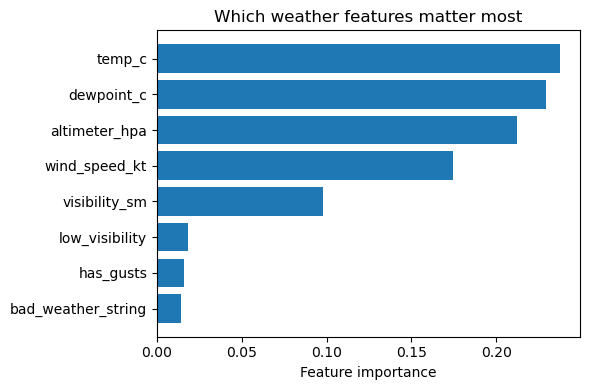

In [106]:
FEATURE_COLS = ["temp_c", "dewpoint_c", "wind_speed_kt", "visibility_sm",
                "altimeter_hpa", "low_visibility", "has_gusts", "bad_weather_string"]

def train_model(data: pd.DataFrame, feature_cols=FEATURE_COLS, save_path: str = MODEL_LOCAL_PATH):
    """Train/test split, fit a RandomForestClassifier, print basic metrics,
    and save the model to disk with joblib."""
    if data.empty:
        print("No processed data to train on yet.")
        return None, {}

    X = data[feature_cols]
    y = data["delayed"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y if y.nunique() > 1 else None
    )

    model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    metrics = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
    }
    print(metrics)

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    joblib.dump(model, save_path)

    importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
    plt.figure(figsize=(6, 4))
    plt.barh(importances.index, importances.values)
    plt.xlabel("Feature importance")
    plt.title("Which weather features matter most")
    plt.tight_layout()
    plt.show()

    return model, metrics


model, train_metrics = train_model(processed)

## 5. `predict_delay()`

Takes a fresh weather reading and returns the predicted probability that a flight departing under those
conditions would be delayed.

In [107]:
def predict_delay(weather_row: dict, model=None, model_path: str = MODEL_LOCAL_PATH,
                   feature_cols=FEATURE_COLS) -> float:
    """Return the predicted probability (0-1) of a delay given current weather.

    `weather_row` should have the same keys used in preprocess_data's feature_cols,
    e.g. {"temp_c": 22, "dewpoint_c": 18, "wind_speed_kt": 12, "visibility_sm": 10,
          "altimeter_hpa": 1015, "low_visibility": 0, "has_gusts": 0, "bad_weather_string": 0}
    """
    if model is None:
        if not os.path.exists(model_path):
            raise FileNotFoundError("No trained model found — run train_model() first.")
        model = joblib.load(model_path)

    row = pd.DataFrame([{c: weather_row.get(c, 0) for c in feature_cols}])
    probability = model.predict_proba(row)[0][1]
    return float(probability)


# Example: normal weather vs. a rough thunderstorm day
calm_day = {"temp_c": 24, "dewpoint_c": 17, "wind_speed_kt": 8, "visibility_sm": 10,
            "altimeter_hpa": 1017, "low_visibility": 0, "has_gusts": 0, "bad_weather_string": 0}
stormy_day = {"temp_c": 26, "dewpoint_c": 24, "wind_speed_kt": 28, "visibility_sm": 2,
              "altimeter_hpa": 1002, "low_visibility": 1, "has_gusts": 1, "bad_weather_string": 1}

if model is not None:
    print("Calm day delay probability:  ", round(predict_delay(calm_day, model), 3))
    print("Stormy day delay probability:", round(predict_delay(stormy_day, model), 3))

Calm day delay probability:   0.231
Stormy day delay probability: 0.388


## 6. `monitor_model()`

Checks the model's accuracy on new/incoming data and prints the result and could possibly send to cloudwatch once we have that set up.

In [108]:
def monitor_model(model, X_new: pd.DataFrame, y_new: pd.Series,
                   push_to_cloudwatch: bool = True) -> dict:
    """Score the model on fresh data and report/alert on performance drops."""
    preds = model.predict(X_new)
    acc = accuracy_score(y_new, preds)
    result = {"accuracy": acc, "n_samples": len(y_new), "checked_at": datetime.utcnow().isoformat()}
    print(f"Monitoring check: accuracy={acc:.3f} on {len(y_new)} samples")

    if push_to_cloudwatch:
        try:
            cw = boto3.client("cloudwatch", region_name=AWS_REGION)
            cw.put_metric_data(
                Namespace="FlightDelayPrediction",
                MetricData=[{
                    "MetricName": "ModelAccuracy",
                    "Value": acc,
                    "Unit": "None",
                }],
            )
        except (NoCredentialsError, ClientError) as e:
            print(f"(CloudWatch metric not sent — {e})")

    return result


ACCURACY_ALERT_THRESHOLD = 0.70  # below this, retrain_model() kicks in

## 7. `retrain_model()`

Simple retraining loop: if `monitor_model()` reports accuracy below the
threshold, pull the latest data, retrain, and only replace the saved model
if the new one is actually better.

In [109]:
def retrain_model(current_model, current_metrics: dict, new_data: pd.DataFrame,
                   feature_cols=FEATURE_COLS, save_path: str = MODEL_LOCAL_PATH):
    """Retrain on new_data and keep whichever model performs better."""
    if new_data.empty:
        print("No new data available to retrain on.")
        return current_model, current_metrics

    candidate_model, candidate_metrics = train_model(new_data, feature_cols, save_path="models/candidate.joblib")

    if candidate_metrics.get("accuracy", 0) > current_metrics.get("accuracy", 0):
        os.replace("models/candidate.joblib", save_path)
        print("New model performs better — replacing the deployed model.")
        return candidate_model, candidate_metrics
    else:
        print("New model did not beat the current one — keeping the existing model.")
        return current_model, current_metrics

## 8. Running the model

C:\Users\evilr\AppData\Local\Temp\ipykernel_21496\4214493513.py:11: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")


Uploaded 2 rows to s3://uncc-dtsc-weatherapp-bucket/raw/metar_20260926T222119Z.json
{'accuracy': 0.7978723404255319, 'precision': 0.8333333333333334, 'recall': 0.11904761904761904}


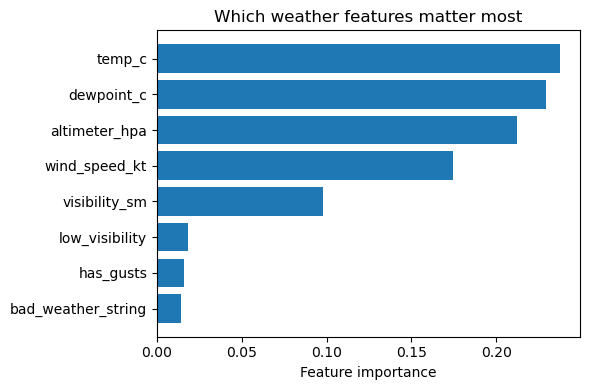

Current delay probability: 0.182
Monitoring check: accuracy=0.802 on 940 samples


C:\Users\evilr\AppData\Local\Temp\ipykernel_21496\4052362440.py:6: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  result = {"accuracy": acc, "n_samples": len(y_new), "checked_at": datetime.utcnow().isoformat()}


In [ ]:
# 1. Collect live weather 
live_weather = collect_weather_data()
store_data_s3(live_weather)

# 2. Train on everything currently in `processed` 
model, metrics = train_model(processed)

# 3. Predict for current conditions
if model is not None and not live_weather.empty:
    latest = live_weather.iloc[-1].to_dict()
    print("Current delay probability:", round(predict_delay(latest, model), 3))

# 4. Monitor + retrain, we can add monthly BTS releases to the processed dataset and retrain if accuracy drops below threshold
if model is not None:
    check = monitor_model(model, processed[FEATURE_COLS], processed["delayed"])
    if check["accuracy"] < ACCURACY_ALERT_THRESHOLD:
        model, metrics = retrain_model(model, metrics, processed)